# Evaluating XAI quality ccross different neural network architectures

This notebook analyzes the quality of explanations generated by Integrated Gradients across three different CIFAR-10 models

| Model           | Description                               |
|-----------------|-------------------------------------------|
| **ResNet-20**   | Lightweight residual network              |
| **ResNet-32**   | Deeper residual network                   |
| **VGG-11 (BN)** | VGG architecture with batch normalization |

We use the "**Monotonicity Correlation**" metric from Quantus to evaluate explanation quality.

## What is Monotonicity?

Monotonicity measures whether removing features identified as important by an attribution method actually decreases the model's confidence. A high monotonicity score means the explanations are faithful - removing "important" pixels truly impacts the prediction.

## Goal

We want to answer:
- **Which architecture produces the most reliable explanations?**
- **Are ResNets or VGGs better for interpretability?**

### 1. Install dependencies

In [44]:
!pip install seaborn
!uv sync

Resolved 155 packages in 0.65ms
Audited 152 packages in 0.86ms


### 2. Load monotonicity metric results

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# load monotonicity results
results_path = os.path.join(
    os.getcwd(), "tests", "data", "measures", "monotonicity_different_models.csv"
)
results = pd.read_csv(results_path)

print("Dataset overview:")
print(f"- {results.head()}")
print(f"\n- Shape: {results.shape}")
print(f"\n- Columns: {", ".join(results.columns.tolist())}")

Dataset overview:
-       model        metric  mean_score  score_0  score_1  score_2  score_3  \
0  resnet20  monotonicity      0.2829   0.0238   0.2486   0.2006   0.2917   
1  resnet32  monotonicity      0.3176   0.3276   0.3654   0.1894   0.2447   
2  vgg11_bn  monotonicity      0.3235   0.3508   0.2864   0.3550   0.2787   

   score_4  score_5  score_6  score_7  score_8  score_9  
0   0.3215   0.3311   0.3200   0.3004   0.3972   0.3944  
1   0.2563   0.4544   0.2764   0.3201   0.3792   0.3627  
2   0.3360   0.3536   0.3519   0.2970   0.3094   0.3159  

- Shape: (3, 13)

- Columns: model, metric, mean_score, score_0, score_1, score_2, score_3, score_4, score_5, score_6, score_7, score_8, score_9


### 3. Data Overview

The table above shows monotonicity scores for each model across 10 test images.

- higher scores closer to 1 indicate better explanation quality
- lower scores means the attributions are less reliable

Each row represents one model, with individual scores for each of the 10 CIFAR-10 test images.

In [46]:
# extract individual scores into a cleaner format for plotting
score_columns = [col for col in results.columns if col.startswith("score_")]
print(f"Found {len(score_columns)} individual image scores")

# verify mean calculation
for idx, row in results.iterrows():
    calculated_mean = row[score_columns].mean()
    print(
        f"{row['model']}: Reported mean = {row['mean_score']:.4f}, Calculated = {calculated_mean:.4f}"
    )

Found 10 individual image scores
resnet20: Reported mean = 0.2829, Calculated = 0.2829
resnet32: Reported mean = 0.3176, Calculated = 0.3176
vgg11_bn: Reported mean = 0.3235, Calculated = 0.3235


### 4. Mean scores per model

This bar chart compares the average monotonicity across all 10 images for each architecture.
A higher bar indicates that the model's explanations are more faithful on average.

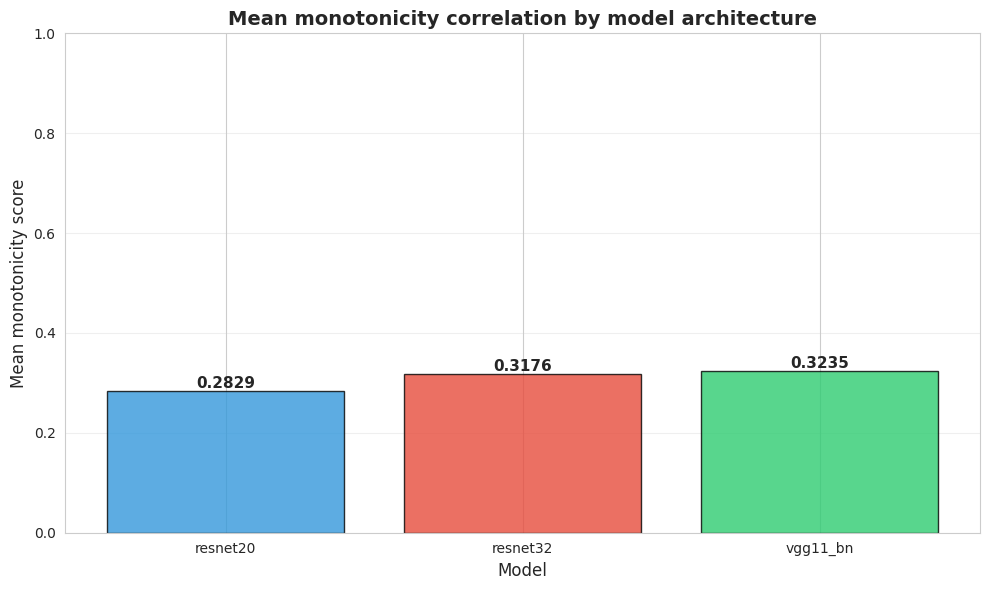


Model ranking (by mean monotonicity):
1. vgg11_bn: 0.3235
2. resnet32: 0.3176
3. resnet20: 0.2829


In [47]:
plt.figure(figsize=(10, 6))

colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = plt.bar(
    results["model"], results["mean_score"], color=colors, alpha=0.8, edgecolor="black"
)

plt.title(
    "Mean monotonicity correlation by model architecture",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Mean monotonicity score", fontsize=12)
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nModel ranking (by mean monotonicity):")
ranked = results.sort_values("mean_score", ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {row['model']}: {row['mean_score']:.4f}")

### 5. Distribution of scores across images

Different images may produce different explanation qualities. This plot shows the distribution of monotonicity scores for each model across all 10 test images.

Box plots reveal:
- **Median performance** (center line)
- **Consistency** (box width = interquartile range)
- **Outliers** (dots outside whiskers)

/tmp/ipykernel_111836/289073339.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, notch=True, showmeans=True)


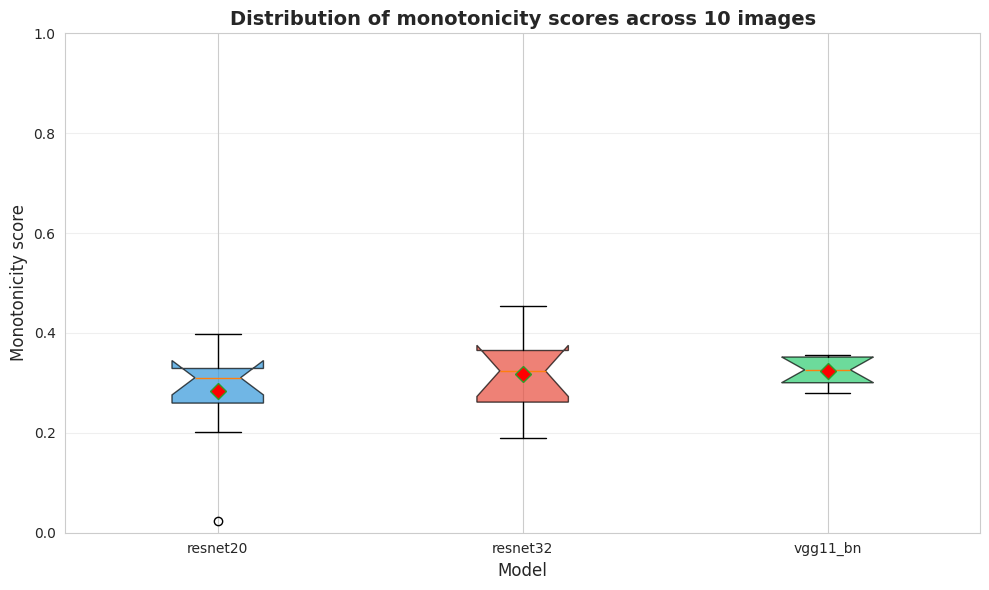


Score statistics by model:

resnet20:
  Mean: 0.2829
  Std:  0.1030
  Min:  0.0238
  Max:  0.3972

resnet32:
  Mean: 0.3176
  Std:  0.0736
  Min:  0.1894
  Max:  0.4544

vgg11_bn:
  Mean: 0.3235
  Std:  0.0282
  Min:  0.2787
  Max:  0.3550


In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

box_data = []
labels = []
for idx, row in results.iterrows():
    scores = row[score_columns].values
    box_data.append(scores)
    labels.append(row["model"])

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, notch=True, showmeans=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for mean in bp["means"]:
    mean.set_marker("D")
    mean.set_markerfacecolor("red")
    mean.set_markersize(8)

ax.set_title(
    "Distribution of monotonicity scores across 10 images",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("Monotonicity score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nScore statistics by model:")
for idx, row in results.iterrows():
    scores = row[score_columns].values
    print(f"\n{row['model']}:")
    print(f"  Mean: {np.mean(scores):.4f}")
    print(f"  Std:  {np.std(scores):.4f}")
    print(f"  Min:  {np.min(scores):.4f}")
    print(f"  Max:  {np.max(scores):.4f}")

### 6. Individual image performance

This heatmap shows how each model performed on each specific test image.

Darker colors mean higher monotonicity (better explanations)

This reveals whether certain images are inherently harder to explain, or if performance varies by architecture.

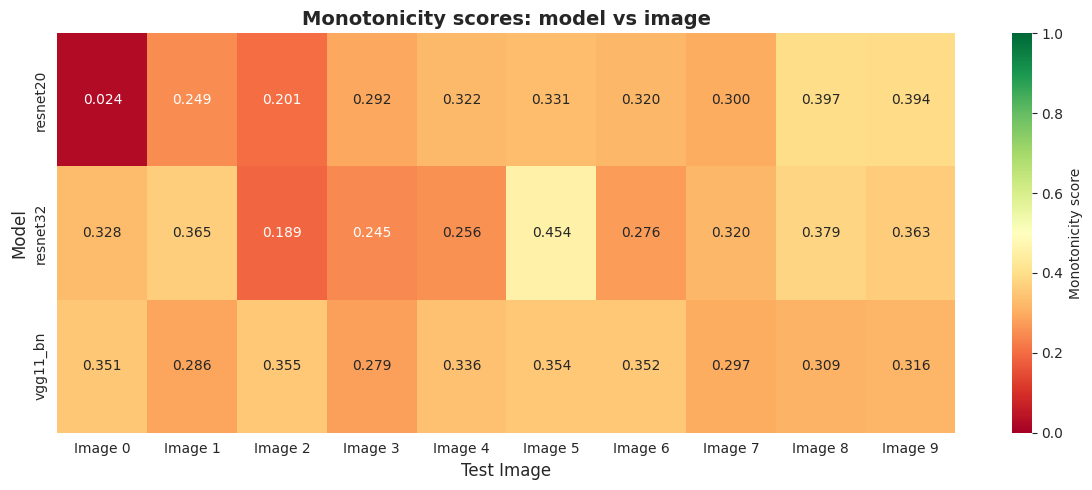

In [49]:
plt.figure(figsize=(12, 5))

score_matrix = results[score_columns].values
image_labels = [f"Image {i}" for i in range(len(score_columns))]

sns.heatmap(
    score_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    xticklabels=image_labels,
    yticklabels=results["model"],
    cbar_kws={"label": "Monotonicity score"},
    vmin=0,
    vmax=1,
)

plt.title("Monotonicity scores: model vs image", fontsize=14, fontweight="bold")
plt.xlabel("Test Image", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.tight_layout()
plt.show()

### 7. Score variability analysis

Consistency is important for reliable explanations. This plot shows the standard deviation of scores for each model.

- **Lower bars** = more consistent explanations across different images
- **Higher bars** = more variability in explanation quality

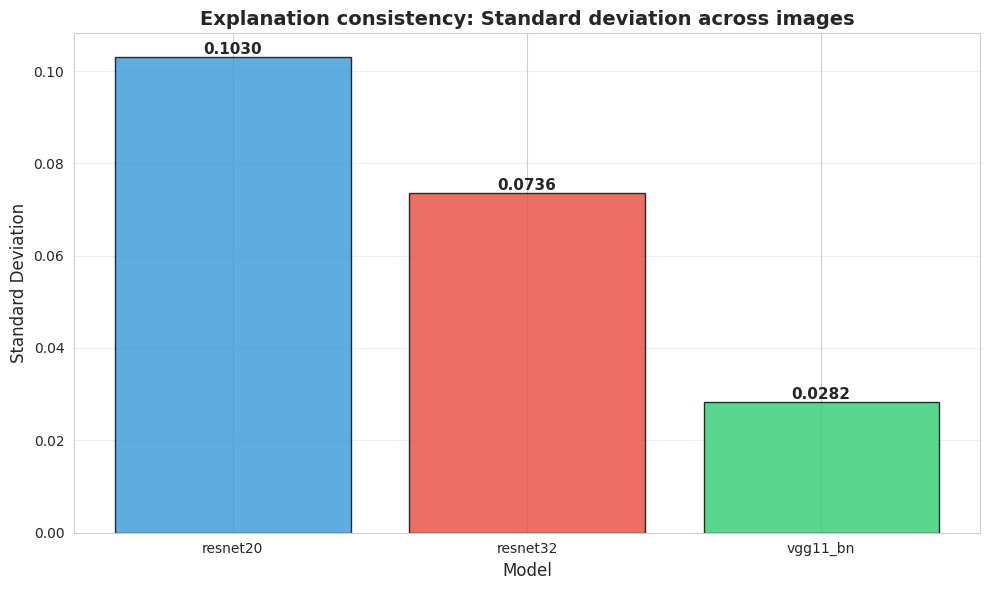


Consistency ranking (lower std = more consistent):
1. vgg11_bn: 0.0282
2. resnet32: 0.0736
3. resnet20: 0.1030


In [50]:
plt.figure(figsize=(10, 6))

std_devs = [
    results.loc[results["model"] == model, score_columns].values.std()
    for model in results["model"]
]

bars = plt.bar(results["model"], std_devs, color=colors, alpha=0.8, edgecolor="black")

plt.title(
    "Explanation consistency: Standard deviation across images",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Standard Deviation", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConsistency ranking (lower std = more consistent):")
consistency_data = pd.DataFrame(
    {"model": results["model"], "std": std_devs}
).sort_values("std")
for i, (idx, row) in enumerate(consistency_data.iterrows(), 1):
    print(f"{i}. {row['model']}: {row['std']:.4f}")

### 8. Per-Image Score Trajectories

This line plot tracks how each model's monotonicity score changes across the 10 test images.

Parallel lines suggest all models struggle or excel with the same images
Diverging lines indicate model-specific sensitivities to certain image characteristics

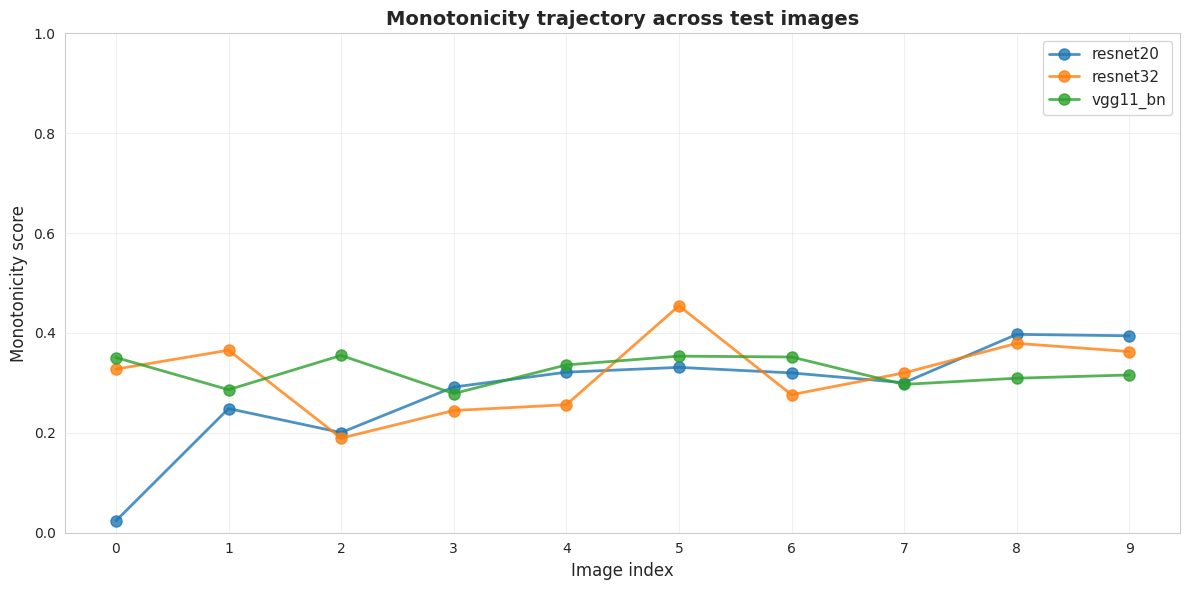


Image difficulty analysis:
Image 0: Average monotonicity = 0.2341
Image 1: Average monotonicity = 0.3001
Image 2: Average monotonicity = 0.2483
Image 3: Average monotonicity = 0.2717
Image 4: Average monotonicity = 0.3046
Image 5: Average monotonicity = 0.3797
Image 6: Average monotonicity = 0.3161
Image 7: Average monotonicity = 0.3058
Image 8: Average monotonicity = 0.3619
Image 9: Average monotonicity = 0.3577


In [51]:
plt.figure(figsize=(12, 6))

for idx, row in results.iterrows():
    scores = row[score_columns].values
    plt.plot(
        range(len(scores)),
        scores,
        marker="o",
        label=row["model"],
        linewidth=2,
        markersize=8,
        alpha=0.8,
    )

plt.title("Monotonicity trajectory across test images", fontsize=14, fontweight="bold")
plt.xlabel("Image index", fontsize=12)
plt.ylabel("Monotonicity score", fontsize=12)
plt.xticks(range(len(score_columns)))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("\nImage difficulty analysis:")
for i in range(len(score_columns)):
    avg_score = results[f"score_{i}"].mean()
    print(f"Image {i}: Average monotonicity = {avg_score:.4f}")

### 9. ResNets vs VGG

Let's group the models by architecture family to see if there are differences between ResNets and VGG.

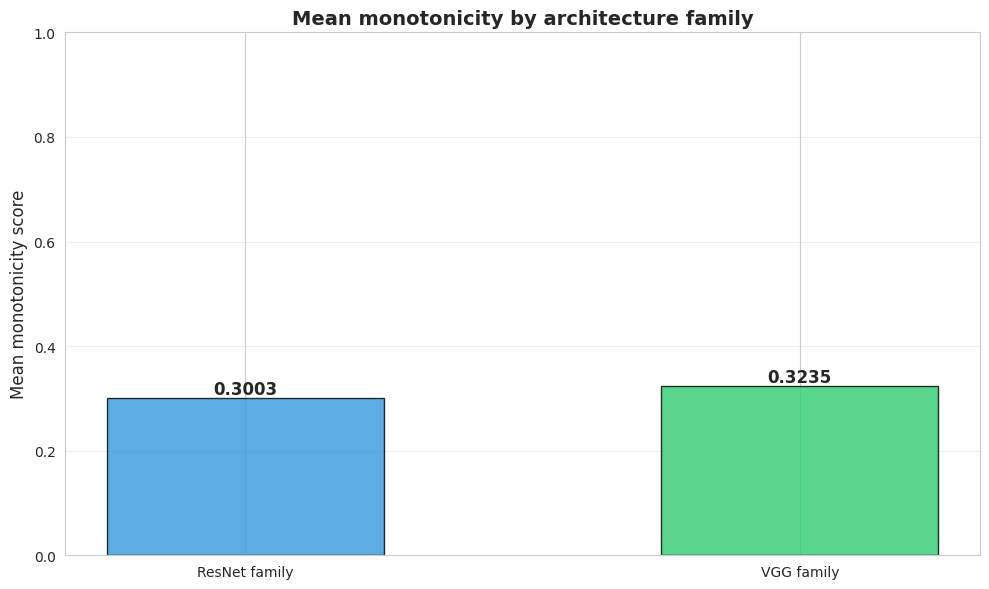


ResNet family average: 0.3003
VGG family average: 0.3235
Difference: 0.0232


In [52]:
plt.figure(figsize=(10, 6))

resnet_models = results[results["model"].str.contains("resnet")]
vgg_models = results[results["model"].str.contains("vgg")]

resnet_mean = resnet_models["mean_score"].mean()
vgg_mean = vgg_models["mean_score"].mean()

architecture_types = ["ResNet family", "VGG family"]
family_means = [resnet_mean, vgg_mean]

bars = plt.bar(
    architecture_types,
    family_means,
    color=["#3498db", "#2ecc71"],
    alpha=0.8,
    edgecolor="black",
    width=0.5,
)

plt.title("Mean monotonicity by architecture family", fontsize=14, fontweight="bold")
plt.ylabel("Mean monotonicity score", fontsize=12)
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nResNet family average: {resnet_mean:.4f}")
print(f"VGG family average: {vgg_mean:.4f}")
print(f"Difference: {abs(resnet_mean - vgg_mean):.4f}")

### 10. Depth vs explanation quality

Does network depth correlate with explanation quality?

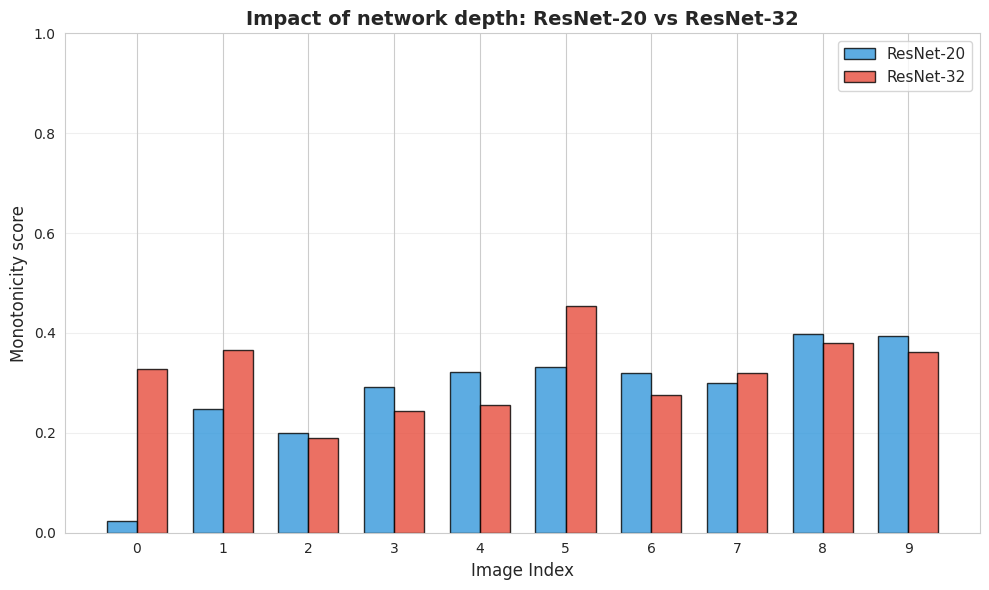


Depth analysis:
ResNet-20 (shallower): Mean = 0.2829, Std = 0.1030
ResNet-32 (deeper):    Mean = 0.3176, Std = 0.0736


In [53]:
plt.figure(figsize=(10, 6))

resnet20_scores = results[results["model"] == "resnet20"][
    score_columns
].values.flatten()
resnet32_scores = results[results["model"] == "resnet32"][
    score_columns
].values.flatten()

x_pos = np.arange(len(resnet20_scores))
width = 0.35

bars1 = plt.bar(
    x_pos - width / 2,
    resnet20_scores,
    width,
    label="ResNet-20",
    color="#3498db",
    alpha=0.8,
    edgecolor="black",
)
bars2 = plt.bar(
    x_pos + width / 2,
    resnet32_scores,
    width,
    label="ResNet-32",
    color="#e74c3c",
    alpha=0.8,
    edgecolor="black",
)

plt.title(
    "Impact of network depth: ResNet-20 vs ResNet-32", fontsize=14, fontweight="bold"
)
plt.xlabel("Image Index", fontsize=12)
plt.ylabel("Monotonicity score", fontsize=12)
plt.xticks(x_pos, [f"{i}" for i in range(len(resnet20_scores))])
plt.legend(fontsize=11)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDepth analysis:")
print(
    f"ResNet-20 (shallower): Mean = {resnet20_scores.mean():.4f}, Std = {resnet20_scores.std():.4f}"
)
print(
    f"ResNet-32 (deeper):    Mean = {resnet32_scores.mean():.4f}, Std = {resnet32_scores.std():.4f}"
)

### 11. Statistical summary

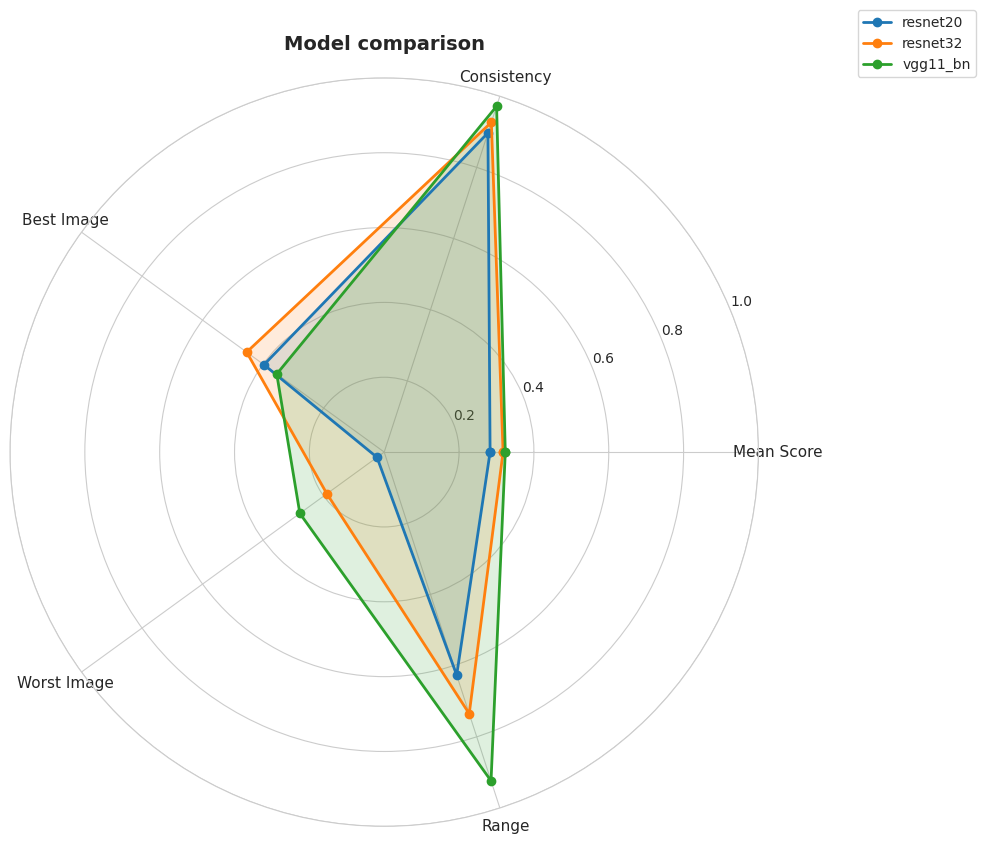


SUMMARY

RESNET20:
  Mean monotonicity: 0.2829
  Consistency (Std): 0.1030
  Best image score:  0.3972
  Worst image score: 0.0238
  Score range:       0.3734

RESNET32:
  Mean monotonicity: 0.3176
  Consistency (Std): 0.0736
  Best image score:  0.4544
  Worst image score: 0.1894
  Score range:       0.2650

VGG11_BN:
  Mean monotonicity: 0.3235
  Consistency (Std): 0.0282
  Best image score:  0.3550
  Worst image score: 0.2787
  Score range:       0.0763


In [54]:
from math import pi

plt.figure(figsize=(10, 10))

categories = ["Mean Score", "Consistency", "Best Image", "Worst Image", "Range"]
N = len(categories)

radar_data = {}
for idx, row in results.iterrows():
    scores = row[score_columns].values
    radar_data[row["model"]] = [
        row["mean_score"],
        1 - scores.std(),
        scores.max(),
        scores.min(),
        1 - (scores.max() - scores.min()),
    ]

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(111, polar=True)

for model_name, values in radar_data.items():
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title("Model comparison", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for idx, row in results.iterrows():
    scores = row[score_columns].values
    print(f"\n{row['model'].upper()}:")
    print(f"  Mean monotonicity: {row['mean_score']:.4f}")
    print(f"  Consistency (Std): {scores.std():.4f}")
    print(f"  Best image score:  {scores.max():.4f}")
    print(f"  Worst image score: {scores.min():.4f}")
    print(f"  Score range:       {scores.max() - scores.min():.4f}")

## Conclusion

### Most Faithful: **VGG-11 (BN)**
- Highest Monotonicity indicates most faithful explanations
- Attributions reliably identify features that impact predictions
- Best choice when explanation quality is critical

### Most Consistent: **VGG-11 (BN)**
- Lowest variability across different images
- More predictable explanation behavior
- Good choice when consistency matters

### Architecture:
The VGG-11 (BN) architecture outperformed both ResNet variants in terms of mean monotonicity and consistency. 